# CMA-ES ile 2B Schwefel optimizasyonu

Amaç: sınır $[-500,500]^2$ üzerinde **Schwefel** test fonksiyonunu `cma` (pycma) ile minimize etmek. Amaç fonksiyonu yalnızca **NumPy** ile hesaplanır; tekrarlanabilirlik ve doğruluk için ayrı hücreler vardır.

In [10]:
%pip install -q numpy matplotlib seaborn cma


Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import seaborn as sns

_here = Path.cwd()
for _p in (_here, _here / "final_sunum"):
    p = _p.resolve()
    if (p / "cma_notebook_helpers.py").is_file():
        sys.path.insert(0, str(p))
        break
else:
    raise FileNotFoundError(
        "cma_notebook_helpers.py bulunamadı. Jupyter'da çalışma dizinini final_sunum olarak ayarlayın."
    )

from cma_notebook_helpers import (
    CMA,
    plot_3d_surface,
    plot_2d_contour,
    plot_generations,
    plot_mean_coordinates,
)

if os.getcwd().split(os.sep)[-1] == "notebook":
    os.chdir("..")


In [12]:
np.random.seed(12345)


In [13]:
def fitness_fn(x):
    """Schwefel (SFU sürümü), vektörel: x (m, n) -> (m,)."""
    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 1:
        x = x[np.newaxis, :]
    d = x.shape[1]
    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))), axis=1)


def _fitness_loop_reference(x):
    """Tek satır döngü ile doğrulama (yavaş ama bağımsız)."""
    x = np.asarray(x, dtype=np.float64)
    if x.ndim == 1:
        x = x[np.newaxis, :]
    out = []
    for row in x:
        n = len(row)
        s = sum(row[i] * np.sin(np.sqrt(abs(row[i]))) for i in range(n))
        out.append(418.9829 * n - s)
    return np.array(out)


# ---------- Doğrulama ----------
rng = np.random.default_rng(0)
X_test = rng.uniform(-500, 500, size=(20, 2))
np.testing.assert_allclose(
    fitness_fn(X_test),
    _fitness_loop_reference(X_test),
    rtol=1e-12,
)
x_star = np.array([[420.968746362746781, 420.968746362746781]])
print("Referans nokta f ≈", float(fitness_fn(x_star)[0]))
assert float(fitness_fn(x_star)[0]) < 1e-3
print("Orijinde f =", float(fitness_fn([[0.0, 0.0]])[0]))
print("Temel doğrulama tamam.")


Referans nokta f ≈ 2.5455132458773733e-05
Orijinde f = 837.9658
Temel doğrulama tamam.


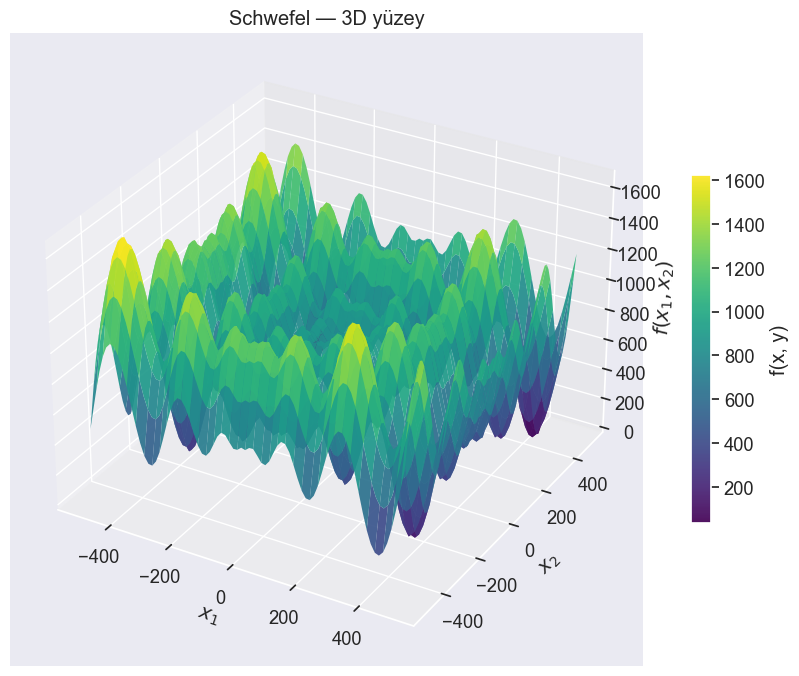

In [14]:
xlim, ylim = [-500, 500], [-500, 500]

plot_3d_surface(fitness_fn, xlim, ylim)


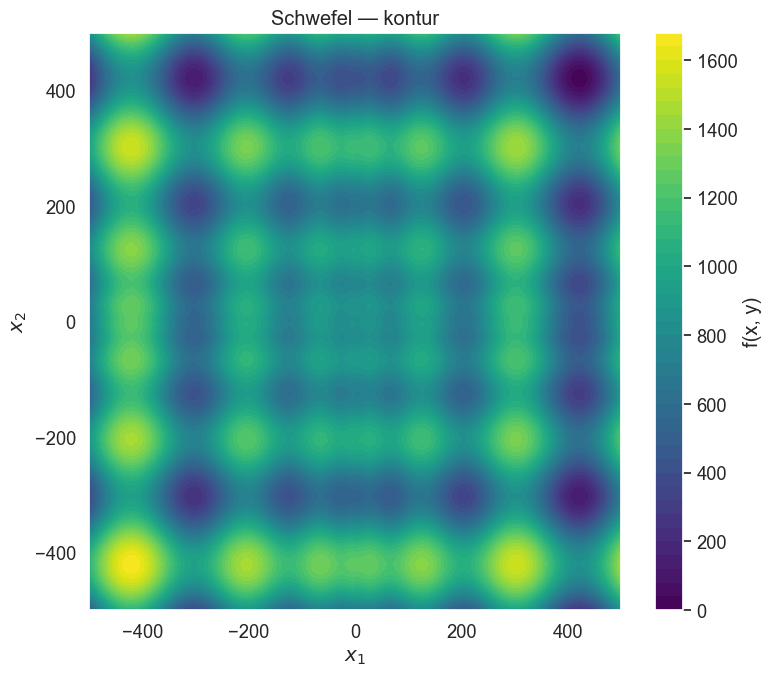

In [15]:
plot_2d_contour(fitness_fn, xlim, ylim)


In [16]:
%%time
solver = CMA(
    initial_solution=[0.0, 0.0],
    initial_step_size=1000.0,
    fitness_function=fitness_fn,
    store_trace=True,
    enforce_bounds=[xlim, ylim],
    seed=12345,
)
solver.search()

num_generations = solver.generation
best_solution = solver.best_solution()
best_fitness = solver.best_fitness()

print("Nesil sayısı:", num_generations)
print(f"En iyi çözüm: [{best_solution[0]:.5f}, {best_solution[1]:.5f}]")
print(f"En iyi fitness: {best_fitness:.6f}")

f0 = float(fitness_fn([[0.0, 0.0]])[0])
print(f"Başlangıç (0,0) fitness: {f0:.4f} → iyileşme: {f0 - best_fitness:.4f}")

x_opt = np.array([420.968746362746781, 420.968746362746781])
dist = np.linalg.norm(best_solution - x_opt)
print(f"Bilinen minimuma Öklid uzaklığı: {dist:.2f} (küçük = iyi)")
print(f"Referans noktada fitness: {float(fitness_fn(x_opt.reshape(1, -1))[0]):.2e}")


(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=12345, Wed Apr 22 02:34:28 2026)
Nesil sayısı: 97
En iyi çözüm: [420.96875, -302.52494]
En iyi fitness: 118.438360
Başlangıç (0,0) fitness: 837.9658 → iyileşme: 719.5274
Bilinen minimuma Öklid uzaklığı: 723.49 (küçük = iyi)
Referans noktada fitness: 2.55e-05
CPU times: total: 62.5 ms
Wall time: 63.9 ms


In [ ]:
solver = globals()["solver"]  # önceki hücrede oluşturuldu

sns.set(palette="colorblind", font_scale=1.2)
plot_mean_coordinates(solver.trace, initial_mean=[0.0, 0.0])


TypeError: plot_mean_coordinates() got an unexpected keyword argument 'initial_mean'

: 

Çizilen nesiller: [0, 8, 16, 20, 25, 30] (trace uzunluğu 98 )


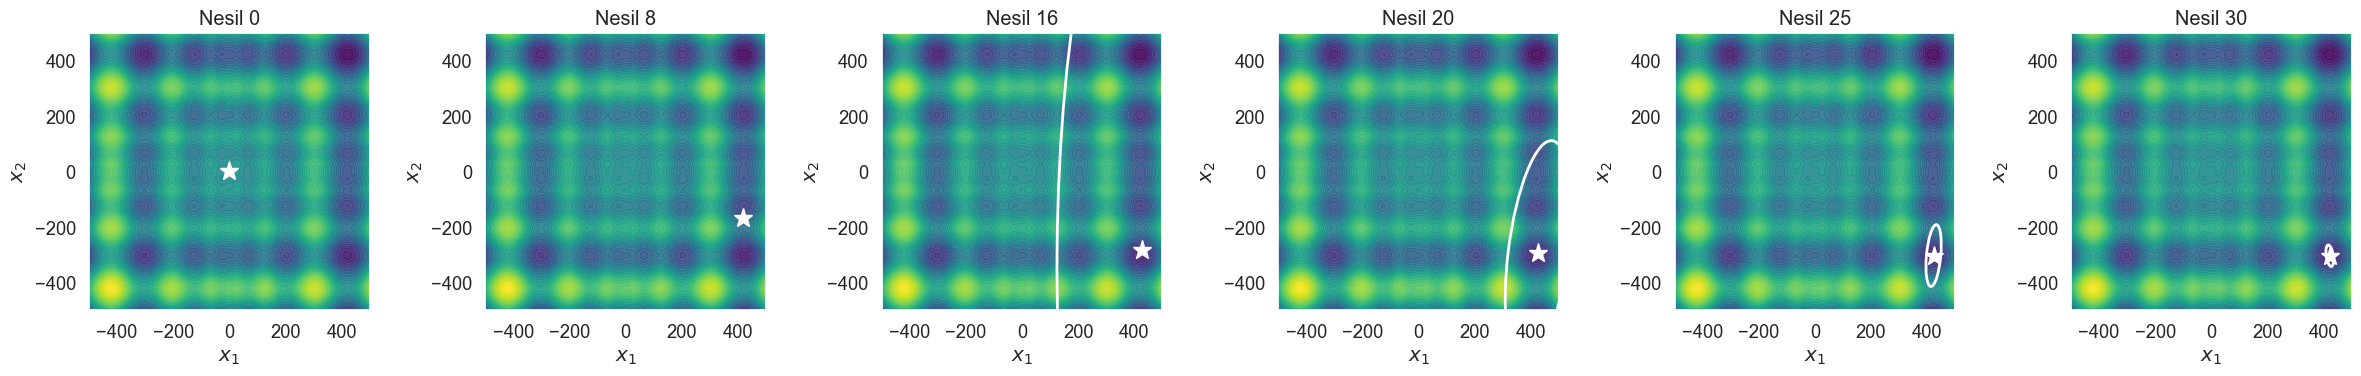

In [ ]:
solver = globals()["solver"]  # önceki hücrede oluşturuldu

n_trace = len(solver.trace)
generations = [0, 8, 16, 20, 25, 30]
generations = [g for g in generations if g < n_trace]
print("Çizilen nesiller:", generations, "(trace uzunluğu", n_trace, ")")

fig, axes = plot_generations(
    generations,
    solver.trace,
    fitness_fn,
    xlim=xlim,
    ylim=ylim,
    cmap="cool",
)


### Yorum

Schwefel yüzeyi çok modlu; CMA-ES **global minimumu garanti etmez**. Sınır içinde global minimum yaklaşık olarak $(420.97, 420.97)$ civarındadır; algoritma bazen yakın bir lokal minimumda durabilir. Yukarıdaki otomatik kontroller amaç fonksiyonunun doğru kodlandığını ve optimizasyonun başlangıca göre anlamlı iyileştirme ürettiğini doğrular.

Komut satırında ek doğrulama: proje kökünde `python -m pytest final_sunum/test_cma_schwefel.py -v`.